In [1]:
%load_ext autoreload
%autoreload 2
from OMPython import ModelicaSystem
import matplotlib.pyplot as plt
from OMPython import OMCSessionZMQ
import pandas as pd
import omc_magic_register as omc_magic
from pathlib import Path


## LINKS
https://openmodelica.org/doc/OpenModelicaUsersGuide/latest/scripting_api.html
https://openmodelica.org/doc/OpenModelicaUsersGuide/latest/ompython.html

## Check connection

+ omc.sendExpression is used behind all other methods. 

In [2]:
# Connect to OpenModelica
omc = OMCSessionZMQ()
print(f"OpenModelica version: {omc.sendExpression('getVersion()')}")
model_path=omc.sendExpression("getInstallationDirectoryPath()")
print(f"OpenModelica installation path: {model_path}")

OpenModelica version: OpenModelica v1.26.1 (64-bit)
OpenModelica installation path: C:/Program Files/OpenModelica1.26.1-64bit


## Control omc with IPython Magic 

How to use magic cells. See source code in [omc_magic_register](omc_magic_register.py)
Below we only register it.
How to: https://ipython.readthedocs.io/en/stable/config/custommagics.html

In [3]:
# register the magic
from IPython.core.magic import register_line_magic, Magics, magics_class, cell_magic, register_cell_magic
from IPython import get_ipython
ip = get_ipython()
ip.register_magics(omc_magic.ModelicaMagics)

OMCSessionZMQ ready. Modelica standard library loaded.
OpenModelica version: OpenModelica v1.26.1 (64-bit)
OpenModelica installation path: C:/Program Files/OpenModelica1.26.1-64bit
Root path: C:/D/proj/PHYS/modelica/omc_work/
Current directory: None


Now we can define modelica code directly in code section.
Magic function is made in such way that it will change working directory to local work folder. Be careful - the code will remove the existing folder before run.

In [4]:
%%modelica
model Simple
  Real x(start=1);
equation
  der(x) = -x;
end Simple;

OpenModelica installation path: C:/Program Files/OpenModelica1.26.1-64bit
model_name: Simple, mode: load, stop_time: 1.0, variables: ['time'], output_format: mat
work dir is not empty and would be deleted
: C:/D/proj/PHYS/modelica/omc_work/work/Simple/
Changed working directory to: C:/D/proj/PHYS/modelica/omc_work/work/Simple/
Loading Modelica code...
None
isModel(Simple) → True


{'success': True,
 'model_name': 'Simple',
 'check': 'Check of Simple completed successfully.\nClass Simple has 1 equation(s) and 1 variable(s).\n1 of these are trivial equation(s).',
 'errors': None}

and even simulate with %%modelica simulate

In [5]:
%%modelica simulate
model Pendulum2
  constant Real g = 9.81;
  parameter Real L = 1.0;
  Real theta(start = 0.5);
  Real omega(start = 0.0);
equation
  der(theta) = omega;
  der(omega) = -(g/L) * sin(theta);
end Pendulum2;

OpenModelica installation path: C:/Program Files/OpenModelica1.26.1-64bit
model_name: Pendulum2, mode: simulate, stop_time: 1.0, variables: ['time'], output_format: mat
work dir is not empty and would be deleted
: C:/D/proj/PHYS/modelica/omc_work/work/Pendulum2/
Changed working directory to: C:/D/proj/PHYS/modelica/omc_work/work/Pendulum2/
Loading Modelica code...
None
isModel(Pendulum2) → True


[OMC log for 'sendExpression(simulate(Pendulum2, stopTime=1.0, outputFormat="mat");, True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").


Simulation failed:
None


{'success': False, 'simulation': None, 'errors': None}

Here another magic to write mos scripts. 
The same in [mos file: test_run_mos_magic.mos](test_run_mos_magic.mos)

In [6]:
%%modelica_script
echo(true)
getVersion()
getInstallationDirectoryPath()
modelFile:="models/MyModel.mo";
loadFile(modelFile);
modelName:="Pendulum";
rootPath :=cd()+"/";
print(rootPath);
currentDir := "";
workDir := "";
runScript("scripts/change_work_dir.mos");
cd()

isModel(Pendulum);
simulate(Pendulum, stopTime=5);
print(getErrorString());
getClassNames()

change ocm dir to root C:/D/proj/PHYS/modelica/omc_work/
cmd: echo(true)
ans: True
cmd: getVersion()
ans: OpenModelica v1.26.1 (64-bit)
cmd: getInstallationDirectoryPath()
ans: C:/Program Files/OpenModelica1.26.1-64bit
cmd: modelFile:="models/MyModel.mo";
cmd: loadFile(modelFile);
cmd: modelName:="Pendulum";
cmd: rootPath :=cd()+"/";
cmd: print(rootPath);
cmd: currentDir := "";
cmd: workDir := "";
cmd: runScript("scripts/change_work_dir.mos");
cmd: cd()
ans: C:/D/proj/PHYS/modelica/omc_work/work/Pendulum
cmd: 
cmd: isModel(Pendulum);
cmd: simulate(Pendulum, stopTime=5);


[OMC log for 'sendExpression(simulate(Pendulum, stopTime=5);, True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").


cmd: print(getErrorString());
cmd: getClassNames()
ans: ('Pendulum', 'Pendulum2', 'Simple', 'ModelicaServices', 'Complex', 'Modelica')


## OMPython.ModelicaSystem

One of the best for mode manipulation is ModelicaSystem

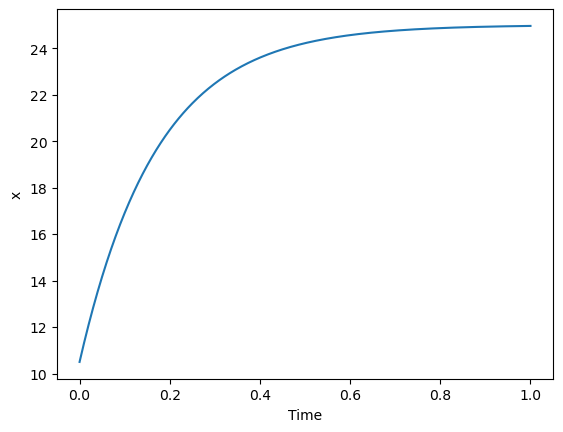

In [7]:
model_file="NewtonCooling.mo"
model_name="NewtonCoolingWithDefaults"

rootPath=Path.resolve(Path(Path.cwd()).parent).as_posix()+"/"
model_full_file = rootPath +"models/"+model_file
# Load a Modelica model (from .mo file or string)
mod = ModelicaSystem(model_full_file, model_name)  # Or use getQuantities() for introspection

# Set parameters if needed
mod.setParameters({"T0": 10.5})

# Simulate
mod.simulate()

# Get results
time = mod.getSolutions("time")
x = mod.getSolutions("T")

# Plot
plt.plot(time[0], x[0])
plt.xlabel("Time")
plt.ylabel("x")
plt.show()

In [8]:
mod.getSimulationOptions()

{'startTime': '0',
 'stopTime': '1',
 'stepSize': '0.002',
 'tolerance': '1e-06',
 'solver': 'dassl',
 'outputFormat': 'mat'}

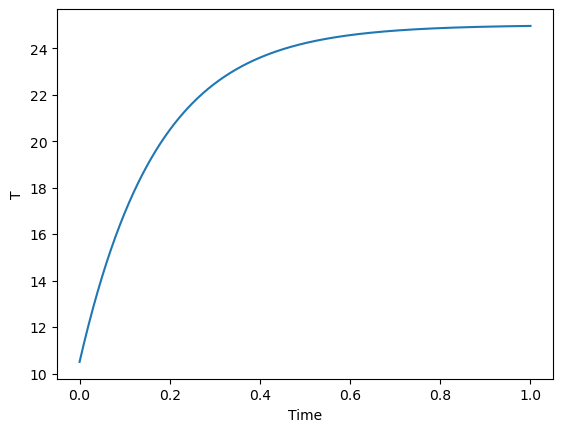

In [9]:
mod.setSimulationOptions(simOptions={'stopTime':5.0})
# mod.simulate(None, None,{'stopTime':20.0})
mod.simulate()
time, T = mod.getSolutions(["time", "T"])
plt.plot(time, T)
plt.xlabel("Time") 
plt.ylabel("T")
plt.show()

In [10]:
sol=mod.getSolutions()
sol

('A', 'T', 'T0', 'T_inf', 'c_p', 'der(T)', 'h', 'm', 'time')

In [11]:
q = pd.DataFrame(mod.getQuantities())
q

,alias,aliasvariable,causality,changeable,description,name,variability,start,min,max,unit
0,noAlias,None,local,false,Temperature,T,continuous,NaN,None,None,None
1,noAlias,None,local,false,der(Temperature),der(T),continuous,NaN,None,None,None
2,noAlias,None,parameter,true,Surface area,A,parameter,1.0,None,None,None
3,noAlias,None,parameter,true,Initial temperature,T0,parameter,90.0,None,None,None
4,noAlias,None,parameter,true,Ambient temperature,T_inf,parameter,25.0,None,None,None
5,noAlias,None,parameter,true,Specific heat,c_p,parameter,1.2,None,None,None
6,noAlias,None,parameter,true,Convective cooling coefficient,h,parameter,0.7,None,None,None
7,noAlias,None,parameter,true,Mass of thermal capacitance,m,parameter,0.1,None,None,None
